<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/Learning-Material/05-Introduction%20to%20LangChain/Module-01/1.2_tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Initial Setup

In [1]:
# Clone the repo
! git clone --depth 1 https://github.com/langchain-ai/lca-lc-foundations.git

Cloning into 'lca-lc-foundations'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 140 (delta 27), reused 85 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 1.09 MiB | 9.31 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [2]:
%cd lca-lc-foundations

/content/lca-lc-foundations


In [3]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-prometheus to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-exporter-prometheus to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install langchain-groq
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get('groq_key')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00


---
What separates an agent from a standard chatbot is its ability to take actions, perceive the output of those actions, and react accordingly.

React Agents use this pattern since most of the industry has coalesced around this method.

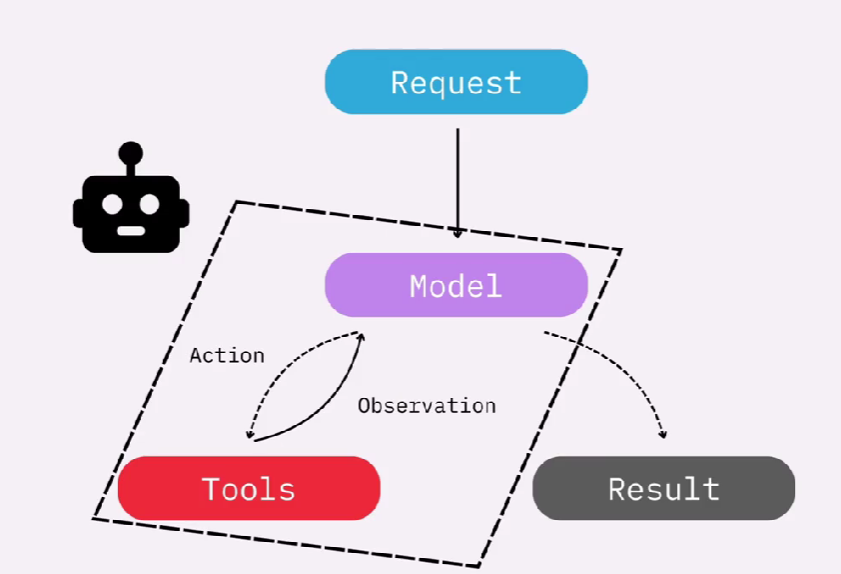

## Tools
The actions that an agent can take are defined by the tools that we provide it. Tools can allow our agent to access data, execute tasks, even call our agents, transforming it from a passive language model to the coordinator of a much more capable system.

In [5]:
from langchain.tools import tool

In [6]:
@tool #decorator that turns it from a function to a tool that the agent can use
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

#you need to make sure your tool's name and description
#are detailed enough for your agent to understand what the tool is and what it actually

By default, the tool's name comes from the function's name, but you can override it with a custom name beside the tool decorator.

Similarly, the tool's description by default comes from this doc string within the function,

but you can override that with a description beside the tool decorator if you'd prefer.

In [7]:
@tool("square_root")
def tool1(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [8]:
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

In [9]:
tool1.invoke({"x": 467})

21.61018278497431

## Building a Calculator using LLM

In [11]:
from langchain.agents import create_agent

In [12]:
@tool
def addition(a:float, b:float) -> float:
  """ Adds two numbers and returns the result """
  return a+b

@tool
def subtract(a:float, b:float) -> float:
  """ Subtracts two numbers and returns the result"""
  return a-b

@tool
def multiply(a:float , b:float) -> float:
  """ Multiplies two numbers and returns the result """
  return a*b

@tool
def divide(a:float, b:float) -> float:
  """ Divides two numbers and returns the result """
  if b == 0:
    raise ValueError("Cannot divide by zero")
  return a/b

@tool
def power(base:float, exponent:float) -> float:
  """ Raises the base to the power of the exponent and returns the result """
  return base**exponent

In [16]:
from langchain_groq import ChatGroq
from google.colab import userdata
from langchain.agents import create_agent

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=userdata.get('groq_key'),
    temperature=0.1,
)
agent = create_agent(model=llm,
                     tools= [addition, subtract , multiply , divide , power],
                     system_prompt='You are a calculator agent. Use your tools to calculate results of user query. If a tool for the query doesn\'t exist then inform the user ad give the answer yourself')

In [21]:
from langchain.messages import HumanMessage
question= HumanMessage(content=input("Enter your Query: "))
response= agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)

Enter your Query: What is the capital of Pakistan?
I am not able to provide the capital of Pakistan as I don't have a specific function for this task. However, I can tell you that the capital of Pakistan is Islamabad.


In [20]:
print(response)

{'messages': [HumanMessage(content='what is 10/3?', additional_kwargs={}, response_metadata={}, id='a97e436f-7e77-435f-8159-7e960139e637'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'eddfa8b00', 'function': {'arguments': '{"a":10,"b":3}', 'name': 'divide'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 519, 'total_tokens': 535, 'completion_time': 0.0641291, 'completion_tokens_details': None, 'prompt_time': 0.062241271, 'prompt_tokens_details': None, 'queue_time': 0.008360538, 'total_time': 0.126370371}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fd8df-5430-7c61-a898-1c5d260c6415-0', tool_calls=[{'name': 'divide', 'args': {'a': 10, 'b': 3}, 'id': 'eddfa8b00', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 519, 'output_tokens': 1